In [1]:
!pip install pandas numpy matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width",        140)
pd.set_option("display.float_format", "{:.3f}".format)

PALETTE = {
    "bg"   : "#FFFFFF",
    "green" : "#32CD32",
    "mid"  : "#E8EDF2",
    "text" : "#000000",
    "blue": "#1B3A6B",
    "red"  : "#E74C3C",
    "grey" : "#555555",
}

CLUSTER_COLORS = ["#32CD32", "#2ECC71", "#3498DB", "#E74C3C", "#9B59B6"]
CLUSTER_NAMES  = {
    0: "Elite Finishers",
    1: "Creative Forwards",
    2: "Wide Attackers",
    3: "Pressing Forwards",
    4: "Box-to-Box Attackers",
}

print("Imports ready")

Imports ready


In [3]:
DATA_PATH         = "scout_data.xlsx" 
FORWARD_POSITIONS = ["ST", "FW", "LW", "RW", "AM"]
MAX_AGE           = 27
MIN_MINS          = 900
N_CLUSTERS        = 5
CLUBS = {
    "Barcelona"          : "Barcelona",
    "Real Madrid"        : "Real Madrid",
    "Atletico Madrid"    : "Atletico Madrid",
    "Manchester City"    : "Manchester City",
    "Manchester United"  : "Manchester United",
    "Liverpool"          : "Liverpool",
    "Chelsea"            : "Chelsea",
    "Arsenal"            : "Arsenal",
    "Tottenham Hotspur"  : "Tottenham",
    "Aston Villa"        : "Aston Villa",
    "AC Milan"           : "AC Milan",
    "Inter Milan"        : "Inter",
    "Juventus"           : "Juventus",
    "Bayern Munich"      : "Bayern Munich",
    "Borussia Dortmund"  : "Borussia Dortmund",
    "Paris Saint Germain": "Paris S-G",
    "Marseille"          : "Marseille",
}

print("Configuration set")
print(f"    Positions  : {FORWARD_POSITIONS}")
print(f"    Max age    : {MAX_AGE}   |   Min minutes : {MIN_MINS}")
print(f"    Clusters   : {N_CLUSTERS}   |   Clubs profiled : {len(CLUBS)}")

Configuration set
    Positions  : ['ST', 'FW', 'LW', 'RW', 'AM']
    Max age    : 27   |   Min minutes : 900
    Clusters   : 5   |   Clubs profiled : 17


In [4]:
def load_and_filter(path, positions, max_age, min_mins):
    raw = pd.read_excel(path, sheet_name="Master Dataset", header=1)
    raw = raw.rename(columns={
        "Player"    : "player",   "Team"      : "team",
        "League"    : "league",   "Nation"    : "nation",
        "Age"       : "age",      "Position"  : "pos",
        "Minutes"   : "minutes",  "Goals"     : "goals",
        "Assists"   : "assists",  "xG"        : "xg",
        "Shots"     : "shots",    "Key Passes": "key_passes",
    })
    num = ["age", "minutes", "goals", "assists", "xg", "shots", "key_passes"]
    raw[num] = raw[num].apply(pd.to_numeric, errors="coerce")
    raw = raw.dropna(subset=["player", "team", "pos"] + num)

    df = raw[
        raw["pos"].isin(positions) &
        (raw["age"]     <= max_age)  &
        (raw["minutes"] >= min_mins)
    ].copy().reset_index(drop=True)
    return df

df_raw = load_and_filter(DATA_PATH, FORWARD_POSITIONS, MAX_AGE, MIN_MINS)

print(f"Dataset loaded — {len(df_raw)} eligible forwards")
print()
print("By position:  ")
print(df_raw["pos"].value_counts().to_string())
print()
print("By league:   ")
print(df_raw["league"].value_counts().to_string())

Dataset loaded — 177 eligible forwards

By position:  
pos
ST    57
RW    40
LW    30
AM    29
FW    21

By league:   
league
ENG-Premier League    53
ITA-Serie A           36
FRA-Ligue 1           30
ESP-La Liga           29
GER-Bundesliga        29


In [5]:
def engineer_features(df):
    d   = df.copy()
    p90 = d["minutes"] / 90 
    d["goals_p90"]    = d["goals"]      / p90
    d["assists_p90"]  = d["assists"]    / p90
    d["xg_p90"]       = d["xg"]         / p90
    d["shots_p90"]    = d["shots"]      / p90
    d["kp_p90"]       = d["key_passes"] / p90
    d["goal_contrib_p90"] = (d["goals"] + d["assists"]) / p90        
    d["shot_conv"]         = d["goals"] / d["shots"].clip(lower=1)   
    d["xg_diff"]           = (d["goals"] - d["xg"]).clip(-5, 5)      
    d["creativity_p90"]    = (d["assists"] + d["key_passes"]) / p90  
    d["attack_vol_p90"]    = (d["shots"]   + d["key_passes"]) / p90  
    return d
    
FEATURES = [
    "goals_p90", "assists_p90", "xg_p90", "shots_p90", "kp_p90",
    "goal_contrib_p90", "shot_conv", "creativity_p90", "attack_vol_p90",
]
df = engineer_features(df_raw)
print("Features engineered:")
print()
stats = df[FEATURES].describe().loc[["mean", "std", "min", "max"]].round(3)
display(stats)

Features engineered:



,goals_p90,assists_p90,xg_p90,shots_p90,kp_p90,goal_contrib_p90,shot_conv,creativity_p90,attack_vol_p90
mean,0.459,0.300,0.020,3.165,2.091,0.759,0.156,2.392,5.256
std,0.209,0.149,0.009,1.183,1.045,0.220,0.073,1.104,1.302
min,0.135,0.047,0.007,1.227,0.540,0.332,0.049,0.750,2.387
max,0.900,0.600,0.036,5.292,4.612,1.170,0.370,5.119,7.757


In [6]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df[FEATURES])
kmeans        = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means fitted (k=5)")
print()
print(f"  {'Cluster':<12} {'Name':<26} {'Players':>8}")
print("  " + "─" * 50)
for c, n in df["cluster"].value_counts().sort_index().items():
    print(f"  C{c:<11} {CLUSTER_NAMES[c]:<26} {n:>8}")

K-Means fitted (k=5)

  Cluster      Name                        Players
  ──────────────────────────────────────────────────
  C0           Elite Finishers                  32
  C1           Creative Forwards                34
  C2           Wide Attackers                   35
  C3           Pressing Forwards                38
  C4           Box-to-Box Attackers             38


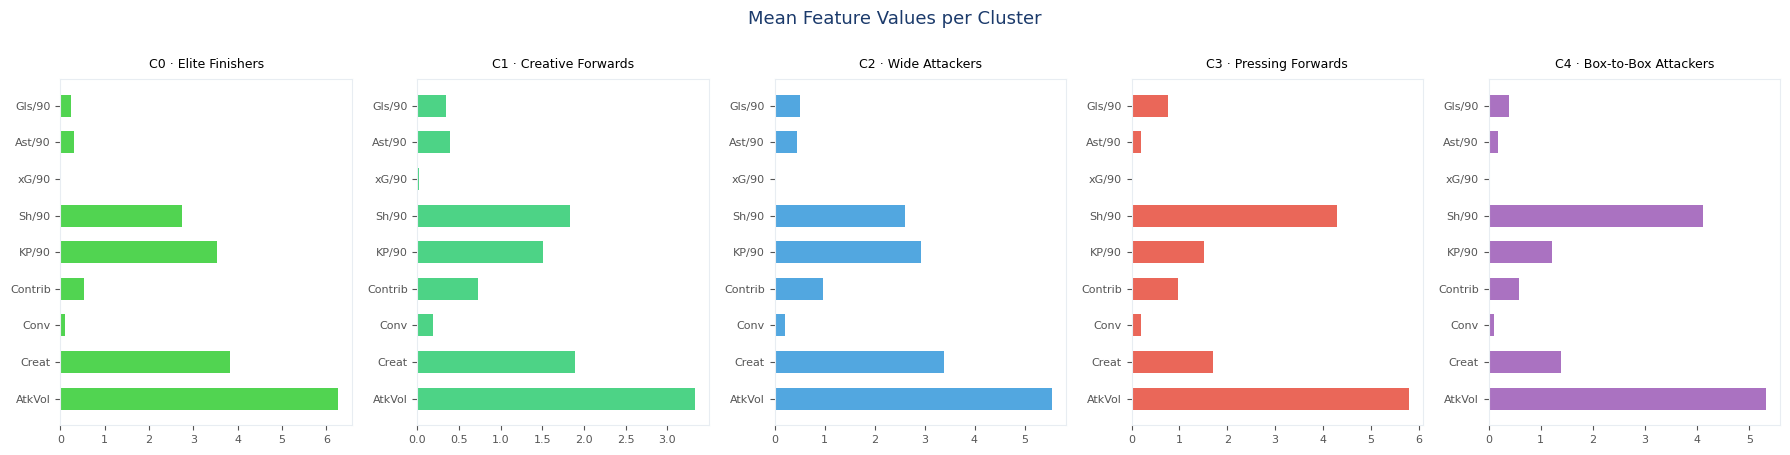

,goals_p90,assists_p90,xg_p90,shots_p90,kp_p90,goal_contrib_p90,shot_conv,creativity_p90,attack_vol_p90
C0 · Elite Finishers,0.238,0.299,0.013,2.735,3.527,0.537,0.091,3.826,6.263
C1 · Creative Forwards,0.338,0.385,0.020,1.829,1.502,0.723,0.190,1.887,3.331
C2 · Wide Attackers,0.510,0.453,0.013,2.613,2.938,0.962,0.210,3.391,5.551
C3 · Pressing Forwards,0.768,0.203,0.028,4.289,1.508,0.971,0.190,1.711,5.798
C4 · Box-to-Box Attackers,0.399,0.183,0.024,4.106,1.213,0.582,0.096,1.396,5.319


In [7]:
FEAT_SHORT = ["Gls/90","Ast/90","xG/90","Sh/90","KP/90","Contrib","Conv","Creat","AtkVol"]
cluster_summary = df.groupby("cluster")[FEATURES].mean().round(3)

fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(18, 4.5), facecolor=PALETTE["bg"])
for i, ax in enumerate(axes):
    vals = cluster_summary.loc[i].values
    ax.barh(FEAT_SHORT, vals, color=CLUSTER_COLORS[i], alpha=0.85, height=0.6)
    ax.set_facecolor(PALETTE["bg"])
    ax.set_title(f"C{i} · {CLUSTER_NAMES[i]}", color=PALETTE["text"], fontsize=9, pad=8)
    ax.tick_params(colors=PALETTE["grey"], labelsize=8)
    [s.set_edgecolor(PALETTE["mid"]) for s in ax.spines.values()]
    ax.invert_yaxis()

plt.suptitle("Mean Feature Values per Cluster", color=PALETTE["blue"], fontsize=13, y=1)
plt.tight_layout(); plt.show()

cluster_summary.index = [f"C{i} · {CLUSTER_NAMES[i]}" for i in cluster_summary.index]
display(cluster_summary)

In [8]:
def build_team_profiles(df, clubs_dict, features, scaler):
    profiles = {}
    print(f"  {'Club':<25} {'Eligible Forwards':>14}")
    print("  " + "─" * 42)
    for display_name, team_name in clubs_dict.items():
        mask = df["team"].str.contains(team_name, case=False, na=False)
        n    = mask.sum()
        if n == 0:
            print(f"   {display_name:<23} — no eligible forwards found")
            continue
        raw_mean = df.loc[mask, features].mean().values.reshape(1, -1)
        profiles[display_name] = {
            "vector"   : scaler.transform(raw_mean)[0],
            "n_players": n,
            "team_name": team_name,
        }
        print(f" * {display_name:<25} {n:>12}")
    return profiles

print("----------------- TEAM PROFILES ----------------------")
team_profiles = build_team_profiles(df, CLUBS, FEATURES, scaler)
print()
print(f"{len(team_profiles)}/{len(CLUBS)} team profiles built successfully.")

----------------- TEAM PROFILES ----------------------
  Club                      Eligible Forwards
  ──────────────────────────────────────────
 * Barcelona                            3
 * Real Madrid                          3
 * Atletico Madrid                      5
 * Manchester City                      2
 * Manchester United                    1
 * Liverpool                            6
 * Chelsea                              8
 * Arsenal                              6
 * Tottenham Hotspur                    5
 * Aston Villa                          3
 * AC Milan                             4
 * Inter Milan                          2
 * Juventus                             6
 * Bayern Munich                        3
 * Borussia Dortmund                    5
 * Paris Saint Germain                  7
 * Marseille                            2

17/17 team profiles built successfully.


In [9]:
def recommend_forwards(club_name, df, profiles, features, X_scaled, n=3):
    if club_name not in profiles:
        print(f"\n  '{club_name}' not in profiles.")
        print("    Available clubs:\n    " + "\n    ".join(sorted(profiles.keys())))
        return None

    profile   = profiles[club_name]
    club_vec  = profile["vector"].reshape(1, -1)
    team_name = profile["team_name"]

    sims                = cosine_similarity(club_vec, X_scaled)[0]
    result              = df.copy()
    result["fit_score"] = np.round(sims, 6)
    result["fit_%"]     = (result["fit_score"] * 100).round(4)

    result = result[~result["team"].str.contains(team_name, case=False, na=False)]

    out_cols = [
        "player","team","league","nation","age","pos","cluster","fit_score","fit_%",
        "minutes","goals_p90","assists_p90","xg_p90","shots_p90","kp_p90",
        "goal_contrib_p90","shot_conv","creativity_p90","attack_vol_p90",
    ]
    recs = (result.sort_values("fit_score", ascending=False)
                  .head(n)[out_cols]
                  .reset_index(drop=True))
    recs.index           = recs.index + 1
    recs["cluster_name"] = recs["cluster"].map(CLUSTER_NAMES)
    return recs


def display_recommendations(recs, club, profiles):
    n_fwds = profiles[club]["n_players"]
    print("=" * 72)
    print(f"   TOP-3 FORWARD TARGETS  ·  {club.upper()}")
    print(f"       Profile built from {n_fwds} eligible forward(s) at club")
    print("=" * 72)

    for rank, row in recs.iterrows():
        print(f"""
  #{rank}  {row['player']} 
      Club     : {row['team']}  ({row['league']})
      Age      : {int(row['age'])}  |  Pos: {row['pos']}  |  Nation: {row['nation']}
      Cluster  : C{int(row['cluster'])} · {row['cluster_name']}
      Minutes  : {int(row['minutes'])}

     || FIT SCORE  {row['fit_%']:.4f}% ||

      Goals/90 : {row['goals_p90']:.3f}    Assists/90 : {row['assists_p90']:.3f}    xG/90     : {row['xg_p90']:.3f}
      Shots/90 : {row['shots_p90']:.3f}    KP/90      : {row['kp_p90']:.3f}    Conv Rate : {row['shot_conv']:.3f}
      G+A/90   : {row['goal_contrib_p90']:.3f}     
  {"─" * 68}""")
    print()


def plot_fit_bars(recs, club):
    fig, ax = plt.subplots(figsize=(9, 3.5), facecolor=PALETTE["bg"])
    ax.set_facecolor(PALETTE["bg"])

    players = recs["player"].values
    scores  = recs["fit_%"].values
    colors  = [CLUSTER_COLORS[int(c)] for c in recs["cluster"].values]

    bars = ax.barh(players[::-1], scores[::-1], color=colors[::-1],
                   height=0.45, edgecolor="none")

    for bar, sc in zip(bars, scores[::-1]):
        ax.text(sc + 0.08, bar.get_y() + bar.get_height() / 2,
                f"{sc:.4f}%", va="center", ha="left",
                color=PALETTE["text"], fontsize=10, fontweight="bold")

    ax.set_xlim(0, max(scores) * 1.22)
    ax.set_xlabel("Fit Score (%)", color=PALETTE["grey"])
    ax.set_title(f"Fit Scores — Top-3 Forwards for {club}",
                 color=PALETTE["text"], fontsize=12, pad=10)
    ax.tick_params(colors=PALETTE["text"], labelsize=10)
    [s.set_edgecolor(PALETTE["mid"]) for s in ax.spines.values()]
    ax.xaxis.set_tick_params(labelcolor=PALETTE["grey"])

    patches = [mpatches.Patch(color=CLUSTER_COLORS[int(c)],
                               label=f"C{int(c)}: {CLUSTER_NAMES[int(c)]}")
               for c in recs["cluster"].unique()]
    ax.legend(handles=patches, facecolor=PALETTE["mid"],
              labelcolor=PALETTE["text"], edgecolor=PALETTE["green"],
              fontsize=8, loc="lower right")
    plt.tight_layout(); plt.show()


def plot_radar(recs, club, profiles, scaler, features):
    radar_feats  = ["goals_p90","assists_p90","xg_p90","shots_p90","kp_p90"]
    radar_labels = ["Goals/90","Assists/90","xG/90","Shots/90","KP/90"]
    N            = len(radar_feats)
    angles       = [n / N * 2 * np.pi for n in range(N)] + [0]

    club_raw  = scaler.inverse_transform(profiles[club]["vector"].reshape(1,-1))[0]
    feat_idx  = [features.index(f) for f in radar_feats]
    club_vals = [club_raw[i] for i in feat_idx] + [club_raw[feat_idx[0]]]

    fig, axes = plt.subplots(1, len(recs), figsize=(5.5 * len(recs), 5.5),
                              subplot_kw=dict(polar=True), facecolor=PALETTE["bg"])
    if len(recs) == 1:
        axes = [axes]

    for ax, (rank, row) in zip(axes, recs.iterrows()):
        ax.set_facecolor(PALETTE["bg"])
        ax.plot(angles, club_vals, color=PALETTE["green"], linewidth=2,
                linestyle="--", label=f"{club} profile")
        ax.fill(angles, club_vals, alpha=0.12, color=PALETTE["green"])

        p_vals = [row[f] for f in radar_feats] + [row[radar_feats[0]]]
        col    = CLUSTER_COLORS[int(row["cluster"])]
        ax.plot(angles, p_vals, color=col, linewidth=2.2, label=row["player"])
        ax.fill(angles, p_vals, alpha=0.22, color=col)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_labels, color=PALETTE["text"], fontsize=9)
        ax.tick_params(colors=PALETTE["grey"])
        ax.set_title(f"#{rank}  {row['player']}\nFit: {row['fit_%']:.4f}%",
                     color=PALETTE["text"], fontsize=10, pad=14)
        ax.legend(facecolor=PALETTE["mid"], labelcolor=PALETTE["text"],
                  edgecolor=PALETTE["green"], fontsize=7,
                  loc="upper right", bbox_to_anchor=(1.4, 1.15))
        ax.grid(color=PALETTE["mid"], linewidth=0.8)
        [s.set_color(PALETTE["mid"]) for s in ax.spines.values()]

    plt.suptitle(f"Radar — {club} Profile vs Top-3 Recommendations",
                 color=PALETTE["text"], fontsize=13, y=1.03)
    plt.tight_layout(); plt.show()


print("All recommendation functions defined")

All recommendation functions defined


---
## AVAILABLE CLUBS
```
  "Barcelona"           "Real Madrid"         "Atletico Madrid"
  "Manchester City"     "Manchester United"   "Liverpool"
  "Chelsea"             "Arsenal"             "Tottenham"
  "Aston Villa"         "AC Milan"            "Inter Milan"
  "Juventus"            "Bayern Munich"       "Borussia Dortmund"
  "Paris Saint-Germain" "Marseille"
```

In [10]:
SELECTED_CLUB = "bayern munich"
recs = recommend_forwards(
    club_name = SELECTED_CLUB,
    df        = df,
    profiles  = team_profiles,
    features  = FEATURES,
    X_scaled  = X_scaled,
    n         = 3,
)

if recs is not None:
    display_recommendations(recs, SELECTED_CLUB, team_profiles)


  'bayern munich' not in profiles.
    Available clubs:
    AC Milan
    Arsenal
    Aston Villa
    Atletico Madrid
    Barcelona
    Bayern Munich
    Borussia Dortmund
    Chelsea
    Inter Milan
    Juventus
    Liverpool
    Manchester City
    Manchester United
    Marseille
    Paris Saint Germain
    Real Madrid
    Tottenham Hotspur


## ── Cell 11 · Fit Score Bar Chart ────────────────────────────────────────

In [11]:
if recs is not None:
    plot_fit_bars(recs, SELECTED_CLUB)

## ── Cell 12 · Radar Chart ────────────────────────────────────────────────

In [12]:
if recs is not None:
    plot_radar(recs, SELECTED_CLUB, team_profiles, scaler, FEATURES)

---
## Cell 16 — Export `scout_data.json`
Run this **once**, after all cells above have run.  
Creates `scout_data.json` in the same folder as this notebook — that file powers the frontend.

In [13]:
import json, os

# Fixes 'int64/float64 is not JSON serializable' error from numpy/pandas
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray):  return obj.tolist()
        return super().default(obj)

print('Exporting scout_data.json...')
print()

# 1. Recommendations — top 10 for every club
recommendations = {}
for club in team_profiles:
    recs_export = recommend_forwards(
        club_name = club,
        df        = df,
        profiles  = team_profiles,
        features  = FEATURES,
        X_scaled  = X_scaled,
        n         = 10,
    )
    if recs_export is None:
        continue
    recommendations[club] = []
    for _, row in recs_export.iterrows():
        recommendations[club].append({
            'player'          : str(row['player']),
            'team'            : str(row['team']),
            'league'          : str(row['league']),
            'nation'          : str(row['nation']),
            'age'             : int(row['age']),
            'pos'             : str(row['pos']),
            'cluster'         : int(row['cluster']),
            'cluster_name'    : CLUSTER_NAMES[int(row['cluster'])],
            'fit_score'       : round(float(row['fit_score']), 6),
            'fit_pct'         : round(float(row['fit_%']), 4),
            'minutes'         : int(row['minutes']),
            'goals_p90'       : round(float(row['goals_p90']),        3),
            'assists_p90'     : round(float(row['assists_p90']),      3),
            'xg_p90'          : round(float(row['xg_p90']),           3),
            'shots_p90'       : round(float(row['shots_p90']),        3),
            'kp_p90'          : round(float(row['kp_p90']),           3),
            'goal_contrib_p90': round(float(row['goal_contrib_p90']), 3),
            'shot_conv'       : round(float(row['shot_conv']),        3),
            'creativity_p90'  : round(float(row['creativity_p90']),   3),
            'attack_vol_p90'  : round(float(row['attack_vol_p90']),   3),
        })
print(f'  recommendations : {len(recommendations)} clubs')

# 2. Top 10 goal scorers by goals_p90
top_scorers_list = []
for _, row in df.nlargest(10, 'goals_p90').iterrows():
    top_scorers_list.append({
        'player'   : str(row['player']),
        'team'     : str(row['team']),
        'league'   : str(row['league']),
        'pos'      : str(row['pos']),
        'age'      : int(row['age']),
        'goals_p90': round(float(row['goals_p90']), 3),
        'minutes'  : int(row['minutes']),
    })
print(f'  top_scorers     : {len(top_scorers_list)} players')

# 3. Top 10 clinical strikers — Goals/90 minus xG/90 (positive = overperforming)
df['clinical_score'] = (df['goals_p90'] - df['xg_p90']).round(4)
top_clinical_list = []
for _, row in df[df['clinical_score'] > 0].nlargest(10, 'clinical_score').iterrows():
    top_clinical_list.append({
        'player'        : str(row['player']),
        'team'          : str(row['team']),
        'league'        : str(row['league']),
        'pos'           : str(row['pos']),
        'age'           : int(row['age']),
        'goals_p90'     : round(float(row['goals_p90']),      3),
        'xg_p90'        : round(float(row['xg_p90']),         3),
        'clinical_score': round(float(row['clinical_score']), 3),
        'minutes'       : int(row['minutes']),
    })
print(f'  top_clinical    : {len(top_clinical_list)} players')

# 4. Club profiles — inverse-transformed back to raw scale for radar charts
club_profiles_out = {}
for club, profile in team_profiles.items():
    raw_vec = scaler.inverse_transform(profile['vector'].reshape(1, -1))[0]
    club_profiles_out[club] = {
        'n_players': int(profile['n_players']),
        'team_name': str(profile['team_name']),
        'features' : dict(zip(FEATURES, [round(float(v), 4) for v in raw_vec])),
    }
print(f'  club_profiles   : {len(club_profiles_out)} clubs')

# 5. Cluster info — names, colours, player counts
cluster_colors_list = ['#32CD32', '#2ECC71', '#3498DB', '#E74C3C', '#9B59B6']
cluster_info = [
    {
        'id'   : int(c_id),
        'name' : c_name,
        'color': cluster_colors_list[c_id],
        'count': int((df['cluster'] == c_id).sum()),
    }
    for c_id, c_name in CLUSTER_NAMES.items()
]
print(f'  cluster_info    : {len(cluster_info)} clusters')

# 6. Assemble everything and write the file
output = {
    'meta': {
        'season'           : '2023-24',
        'total_players'    : int(len(df)),
        'leagues'          : sorted(df['league'].unique().tolist()),
        'clubs_profiled'   : int(len(club_profiles_out)),
        'features'         : FEATURES,
        'forward_positions': FORWARD_POSITIONS,
        'max_age'          : int(MAX_AGE),
        'min_minutes'      : int(MIN_MINS),
        'n_clusters'       : int(N_CLUSTERS),
    },
    'recommendations': recommendations,
    'top_scorers'    : top_scorers_list,
    'top_clinical'   : top_clinical_list,
    'club_profiles'  : club_profiles_out,
    'cluster_info'   : cluster_info,
}

with open('scout_data.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, indent=2, ensure_ascii=False, cls=NpEncoder)

size_kb = os.path.getsize('scout_data.json') / 1024
print()
print(f'scout_data.json saved ({size_kb:.1f} KB)')
print(f'Location : {os.path.abspath("scout_data.json")}')
print()
print('Done — you can now run the frontend.')


Exporting scout_data.json...

  recommendations : 17 clubs
  top_scorers     : 10 players
  top_clinical    : 10 players
  club_profiles   : 17 clubs
  cluster_info    : 5 clusters

scout_data.json saved (115.0 KB)
Location : C:\Users\JASMANDEEP SINGH\fullstack\scout_data.json

Done — you can now run the frontend.
